In [1]:
import gc
import pickle

from pathlib import Path

import numpy as np

from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, to_tree
from scipy.stats import ks_2samp

from sklearn.metrics import pairwise_distances
from statsmodels.stats.multitest import multipletests

import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import seaborn as sns

import anndata as ad
import scanpy as sc

np.random.seed(0)

%matplotlib inline

In [2]:
## Colors ##

red_cmap = LinearSegmentedColormap.from_list("red_smooth",["#fff5f0", "#fcbba1", "#fb6a4a", "#cb181d"])
red_cmap = LinearSegmentedColormap.from_list("red_smooth",["#fff5f0", "#fcbba1", "#fc9272", "#cb181d"])

# light_blue_cmap = LinearSegmentedColormap.from_list("light_blue_smooth", ['#d2e2e7', '#8fb7c5', '#1f6f8b'])
light_blue_cmap = LinearSegmentedColormap.from_list("light_blue_smooth", ['#d2e2e7', '#a5c5d0', '#1f6f8b'])

# blue_cmap = LinearSegmentedColormap.from_list("blue_smooth", ['#ece7f2', '#a6bddb', '#0570b0'])
blue_cmap = LinearSegmentedColormap.from_list("blue_smooth", ['#ece7f2', '#a6bddb', '#084594'])

green_cmap = LinearSegmentedColormap.from_list("green_smooth", ['#d6e7e5ff', '#7aa5a1ff', '#1c4442ff'])

rainbow_cmap = LinearSegmentedColormap.from_list("rainbow", [
    "#313695",
    "#4575b4",
    "#74add1",
    "#abd9e9",
    "#e0f3f8",
    "#ffffbf",
    "#fee090",
    "#fdae61",
    "#f46d43",
    "#d73027",
    "#a50026"])

In [ ]:
## Import Organoid Data ##

scz_adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata_annotated_w_celltypist_scanvi.h5ad')

# remove stressed glia and doublets
scz_adata = scz_adata[(~scz_adata.obs['pred_dbl'])].copy()

# define pseudobulk column 
scz_adata.obs['Donor_Sample'] = scz_adata.obs['Donor'].astype('str') + '_' + scz_adata.obs['Sample Name'].astype('str')
scz_adata.obs['Donor_Sample_Celltype'] = scz_adata.obs['Donor_Sample'] + '_' + scz_adata.obs['CellType'].astype('str')
gc.collect()

In [ ]:
# ei branch probs
branch_probs_ei = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/trajectory_analyses/ei_branch_probs.csv', index_col=0)
branch_probs_di = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/trajectory_analyses/direct_indirect_branch_probs.csv', index_col=0)
branch_probs_di['Broad_Genotype'] = scz_adata.obs['Broad_Genotype']

## pickle load gene trends
in_path = "/mnt/sdb/scz_meta_analysis_processed/trajectory_analyses/ei_gene_trends.pkl"

with open(in_path, "rb") as f:
    gene_trends = pickle.load(f)

In [ ]:
## Create Adata Objects ##

ei_adata = scz_adata[branch_probs_ei.index].copy()
di_adata = scz_adata[branch_probs_di.index].copy()

# add constants for grouping if necessary
ei_adata.obs['constant'] = 1
di_adata.obs['constant'] = 1

# merge on palantir series cols 
di_adata.obs = di_adata.obs.merge(branch_probs_di[['Direct', 'Indirect', 'palantir_pseudotime', 'Path',
                                                'palantir_entropy', 'assignment']], 
                                  left_index=True, right_index=True, how='left')

di_adata.obs['Path'] = di_adata.obs['Path'].astype('str')

ei_adata.obs = ei_adata.obs.merge(branch_probs_ei[['Excitatory', 'Inhibitory', 'palantir_pseudotime', 'Path',
                                                'palantir_entropy', 'assignment']], 
                                  left_index=True, right_index=True, how='left')

ei_adata.obs['Path'] = ei_adata.obs['Path'].astype('str')

# add broad genotype path
ei_adata.obs['Broad_Genotype_Path'] = ei_adata.obs['Broad_Genotype'].astype('str') + '_' + ei_adata.obs['Path'].astype('str')
di_adata.obs['Broad_Genotype_Path'] = di_adata.obs['Broad_Genotype'].astype('str') + '_' + di_adata.obs['Path'].astype('str')

## calculate neighbors 

sc.pp.neighbors(ei_adata, n_neighbors=15, use_rep='X_scVI')
sc.pp.neighbors(di_adata, n_neighbors=15, use_rep='X_scVI')

In [ ]:
## Recalculate linear pseudotime for DI anndata ##

# 1. Define mask
mask = ((di_adata.obs['subclass_annotations'] == 'Radial Glia') & (di_adata.obs['Day'] == 22))

# 2. Get indices in full AnnData
subset_idx = np.where(mask)[0]

# 3. Pull scVI latent space
X = di_adata.obsm['X_scVI'][subset_idx]

# 4. Compute centroid in scVI space
centroid = X.mean(axis=0)

# 5. Find closest cell
dists = pairwise_distances(X, centroid.reshape(1, -1)).ravel()
closest_local_idx = np.argmin(dists)

# 6. Map back to original index
iroot = subset_idx[closest_local_idx]

# 7. Set root
di_adata.uns['iroot'] = int(iroot)

## Calculate linear pseudotime
sc.tl.diffmap(di_adata)
sc.tl.dpt(di_adata)

In [ ]:
sc.pl.umap(ei_adata, color='subtype_cluster_annotations')

In [ ]:
sc.pl.umap(ei_adata, color="subtype_cluster_annotations", show=False, legend_loc=None, title=None, frameon=False)

ax = plt.gca()
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("")

# save figure
plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_6_excitatory_inhibitory_clusters_umap.png", 
            transparent=True,
            dpi=500, bbox_inches="tight")
plt.show()

In [ ]:
EXC_COLOR = "#d8b365"   # muted terracotta
INH_COLOR = "#5ab4ac"   # dusty cornflower

ei_adata.uns["Path_colors"] = [EXC_COLOR, INH_COLOR]

In [ ]:
sc.pl.umap(ei_adata, color='Path', frameon=False)

In [ ]:
sc.pl.umap(ei_adata, color="Path", show=False, legend_loc=None, title=None, frameon=False)

ax = plt.gca()
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("")

# save figure
plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_6_excitatory_inhibitory_path_umap.png", 
            dpi=500, transparent=True,
            bbox_inches="tight")
plt.show()

In [ ]:
sc.pl.umap(ei_adata, color='palantir_pseudotime', frameon=False, cmap=rainbow_cmap, vmax='p99.9')

In [ ]:
sc.pl.umap(ei_adata, color="palantir_pseudotime", show=False, legend_loc=None, title=None, 
           frameon=False, cmap=rainbow_cmap, vmax='p99.9')

ax = plt.gca()
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("")

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_6_excitatory_inhibitory_pseudotime_umap.png", 
            dpi=500, bbox_inches="tight")
plt.show()

In [ ]:
sc.pl.umap(di_adata, color='subtype_cluster_annotations_markers')

In [ ]:
sc.pl.umap(di_adata, color="subtype_cluster_annotations_markers", show=False, legend_loc=None, title=None, frameon=False)

ax = plt.gca()
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("")

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_6_direct_indirect_clusters_umap.png", transparent=False, 
            dpi=500, bbox_inches="tight")
plt.show()

In [ ]:
sc.pl.umap(di_adata, color='dpt_pseudotime')

In [ ]:
sc.pl.umap(di_adata, color="dpt_pseudotime", show=False, legend_loc=None, title=None, frameon=False, cmap=rainbow_cmap) #, vmax='p99')

ax = plt.gca()
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("")

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_6_direct_indirect_pseudotime_umap.png", 
            transparent=True,
            dpi=500, bbox_inches="tight")
plt.show()

In [ ]:
DIRECT_COLOR = "#d8b365"   # muted terracotta
INDIRECT_COLOR = "#5ab4ac"   # dusty cornflower

di_adata.obs['Path'] = di_adata.obs['Path'].astype('str')

di_adata.uns['Path_colors'] = [DIRECT_COLOR, INDIRECT_COLOR]

In [ ]:
sc.pl.umap(di_adata, color='Path')

In [ ]:
di_adata.obs["Path"] = di_adata.obs["Path"].astype("category")
sc.pl.umap(di_adata, color="Path", show=False, legend_loc=None, title=None, frameon=False)

ax = plt.gca()
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("")

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_6_direct_indirect_path_umap.png", transparent=True,
            dpi=500, bbox_inches="tight")
plt.show()

In [ ]:
## Test Trajectory Speed ##

pt = (
    di_adata.obs
    .groupby("Donor_Sample")
    .agg(
        mean_pseudotime=("palantir_pseudotime", "mean"),
        median_pseudotime=("palantir_pseudotime", "median"),
        n_cells=("palantir_pseudotime", "size"),
        diagnosis=("Broad_Genotype", "first"),
        donor=("Donor", "first")
    )
    .reset_index()
)

In [ ]:
bins = np.arange(0, 175, 25)
labels = [f"{i}-{i+25}" for i in bins[:-1]]
di_adata.obs["Day_bin"] = pd.cut(di_adata.obs["Day"], bins=bins, labels=labels, include_lowest=True)

fig, ax = plt.subplots(figsize=(5,4))

sns.violinplot(data=di_adata.obs, x="Day_bin", y="palantir_pseudotime", cut=0, ax=ax)

ax.set(xlabel="", ylabel="", title="")
ax.tick_params(axis="x", rotation=45, labelsize=10)
ax.set_xticklabels(ax.get_xticklabels(), ha='right')  # Align x-axis labels to the right
sns.despine()

plt.tight_layout()
# plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Trajectory_di_violin_pseudotime_by_day.svg",
#             dpi=300, bbox_inches="tight")
plt.show()

In [58]:
summary_nrxn1 = pd.read_csv("/mnt/sdb/scz_meta_analysis_processed/trajectory_analyses/meta_nrxn1.csv")
summary_idio = pd.read_csv("/mnt/sdb/scz_meta_analysis_processed/trajectory_analyses/meta_idio.csv")
summary_22q11 = pd.read_csv("/mnt/sdb/scz_meta_analysis_processed/trajectory_analyses/meta_22q11.csv")

meta_df = pd.read_csv("/mnt/sdb/scz_meta_analysis_processed/trajectory_analyses/meta_df.csv")
summary_3q29 = meta_df[meta_df['term'] == 'Broad_GenotypeX3q29del']
summary_3q29.rename({'term':'origin', 'beta':'estimate'}, axis=1, inplace=True)
summary_3q29['origin'] = summary_3q29['origin'].str.replace('Broad_GenotypeX','')
summary_3q29["ci.lb"] = summary_3q29["estimate"] - 1.96 * summary_3q29["se"]
summary_3q29["ci.ub"] = summary_3q29["estimate"] + 1.96 * summary_3q29["se"]

summary_15q13 = meta_df[meta_df['term'] == 'Broad_GenotypeX15q13.3del']
summary_15q13.rename({'term':'origin', 'beta':'estimate'}, axis=1, inplace=True)
summary_15q13['origin'] = summary_15q13['origin'].str.replace('Broad_GenotypeX','')
summary_15q13["ci.lb"] = summary_15q13["estimate"] - 1.96 * summary_15q13["se"]
summary_15q13["ci.ub"] = summary_15q13["estimate"] + 1.96 * summary_15q13["se"]

/tmp/ipykernel_150643/2045509936.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary_3q29.rename({'term':'origin', 'beta':'estimate'}, axis=1, inplace=True)
/tmp/ipykernel_150643/2045509936.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary_3q29['origin'] = summary_3q29['origin'].str.replace('Broad_GenotypeX','')
/tmp/ipykernel_150643/2045509936.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pan

In [59]:
fe_traj = pd.concat([summary_nrxn1.assign(origin='NRXN1'), 
           summary_idio.assign(origin='idio'), 
           summary_22q11.assign(origin='22q11'), 
                    summary_3q29,summary_15q13], axis=0)

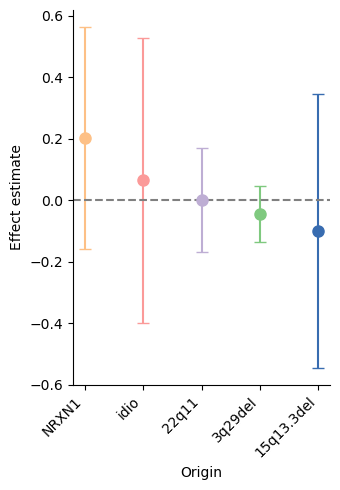

In [72]:

df = fe_traj.dropna(subset=["estimate", "ci.lb", "ci.ub"]).copy()

# Match your origin names exactly
color_map = {
    "3q29del": "#7fc97f",
    "22q11": "#beaed4",
    "NRXN1": "#fdc086",
    "idio": "#fb9a99",      # change to "idiopathic" if that's what's in your dataframe
    "15q13.3del": "#386cb0"
}

x = np.arange(len(df))

fig, ax = plt.subplots(figsize=(3.5, 5))

for i, (_, row) in enumerate(df.iterrows()):
    color = color_map.get(row["origin"], "black")

    ax.errorbar(
        x=i,
        y=row["estimate"],
        yerr=[[row["estimate"] - row["ci.lb"]],
              [row["ci.ub"] - row["estimate"]]],
        fmt="o",
        color=color,
        ecolor=color,
        capsize=4,
        markersize=8
    )

ax.axhline(0, color="gray", linestyle="--")

ax.set_xticks(x)
ax.set_xticklabels(df["origin"], rotation=45, ha="right")

ax.set_ylabel("Effect estimate")
ax.set_xlabel("Origin")
sns.despine()
plt.tight_layout()
plt.show()

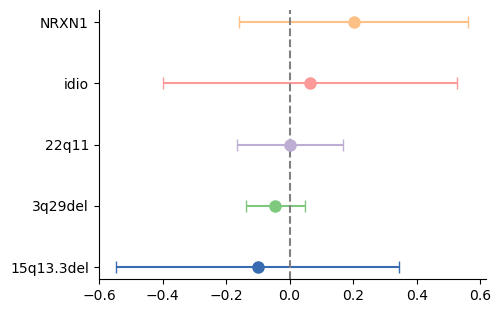

In [78]:
import matplotlib.pyplot as plt
import numpy as np

df = fe_traj.dropna(subset=["estimate", "ci.lb", "ci.ub"]).copy()

# Optional: reverse order so first row appears at the top
df = df.iloc[::-1]

color_map = {
    "3q29del": "#7fc97f",
    "22q11": "#beaed4",
    "NRXN1": "#fdc086",
    "idio": "#fb9a99",      # change to "idiopathic" if needed
    "15q13.3del": "#386cb0"
}

y = np.arange(len(df))

fig, ax = plt.subplots(figsize=(5, 3.5))

for i, (_, row) in enumerate(df.iterrows()):
    color = color_map.get(row["origin"], "black")

    ax.errorbar(
        x=row["estimate"],
        y=i,
        xerr=[[row["estimate"] - row["ci.lb"]],
              [row["ci.ub"] - row["estimate"]]],
        fmt="o",
        color=color,
        ecolor=color,
        capsize=4,
        markersize=8
    )

# Line of no effect
ax.axvline(0, color="gray", linestyle="--")

ax.set_yticks(y)
ax.set_yticklabels(df["origin"])

#ax.set_xlabel("Effect estimate")
#ax.set_ylabel("Origin")
sns.despine()
plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_6_trajectory_forest_plot.svg", dpi=500, bbox_inches="tight")
plt.show()

In [70]:
import numpy as np
import pandas as pd

from scipy.stats import ks_2samp
from statsmodels.stats.multitest import multipletests

# ----------------------------
# Cell-level pseudotime
# ----------------------------
cell_df = (
    di_adata.obs[["Broad_Genotype", "palantir_pseudotime"]]
    .dropna()
    .copy()
)

# ----------------------------
# References
# ----------------------------
control = cell_df.loc[
    cell_df.Broad_Genotype == "Control",
    "palantir_pseudotime"
]

idio = cell_df.loc[
    cell_df.Broad_Genotype == "Idiopathic_Schizophrenia",
    "palantir_pseudotime"
]

results = []

for group in sorted(cell_df.Broad_Genotype.unique()):

    if group == "Control":
        continue

    vals = cell_df.loc[
        cell_df.Broad_Genotype == group,
        "palantir_pseudotime"
    ]

    # vs Control
    ks_c, p_c = ks_2samp(vals, control)

    # vs Idiopathic
    if group != "Idiopathic_Schizophrenia":
        ks_i, p_i = ks_2samp(vals, idio)

        mean_i = vals.mean() - idio.mean()
        median_i = vals.median() - idio.median()

    else:
        ks_i = np.nan
        p_i = np.nan
        mean_i = np.nan
        median_i = np.nan

    results.append({
        "group": group,

        "mean_vs_control": vals.mean() - control.mean(),
        "median_vs_control": vals.median() - control.median(),
        "ks_vs_control": ks_c,
        "p_vs_control": p_c,

        "mean_vs_idio": mean_i,
        "median_vs_idio": median_i,
        "ks_vs_idio": ks_i,
        "p_vs_idio": p_i
    })

results = pd.DataFrame(results)

results["p_vs_control_adj"] = multipletests(
    results["p_vs_control"],
    method="fdr_bh"
)[1]

mask = results["p_vs_idio"].notna()

results.loc[mask, "p_vs_idio_adj"] = multipletests(
    results.loc[mask, "p_vs_idio"],
    method="fdr_bh"
)[1]

results = results.sort_values("mean_vs_control")

results

,group,mean_vs_control,median_vs_control,ks_vs_control,p_vs_control,mean_vs_idio,median_vs_idio,ks_vs_idio,p_vs_idio,p_vs_control_adj,p_vs_idio_adj
3,Idiopathic_Schizophrenia,-0.078665,-0.095877,0.194040,4.506173e-32,NaN,NaN,NaN,NaN,4.506173e-32,NaN
2,3q29del,-0.068163,-0.143088,0.226672,8.021551e-106,0.010502,-0.047211,0.133139,3.688489e-11,1.002694e-105,3.688489e-11
4,NRXN1del,0.044272,0.130091,0.098847,9.819266e-264,0.122936,0.225968,0.289064,4.429846e-71,2.454816e-263,5.906461e-71
1,22q11.2del,0.048263,0.151446,0.117942,1.259365e-187,0.126928,0.247323,0.306311,1.542549e-77,2.098941e-187,3.085099e-77
0,15q13.3del,0.133900,0.180896,0.472099,0.000000e+00,0.212564,0.276773,0.634676,1.307320e-270,0.000000e+00,5.229279e-270


/tmp/ipykernel_150643/2541582933.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


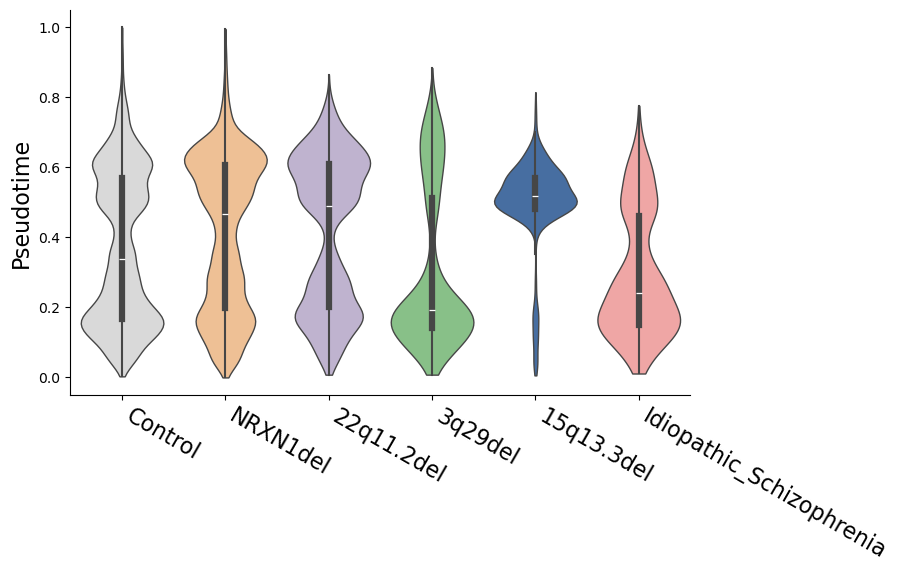

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

palette = {
    "3q29del": "#7fc97f",
    "15q13.3del": "#386cb0",
    "22q11.2del": "#beaed4",
    "Control": "#d9d9d9",
    "Idiopathic_Schizophrenia": "#fb9a99",
    "NRXN1del": "#fdc086",
}

order = [
    "Control",
    "NRXN1del",
    "22q11.2del",
    "3q29del",
    "15q13.3del",
    "Idiopathic_Schizophrenia"
]

plt.figure(figsize=(8, 5))

sns.violinplot(
    data=di_adata.obs,
    x="Broad_Genotype",
    y="palantir_pseudotime",
    order=order,
    palette=palette,
#    inner="quartile",
    cut=0,
    linewidth=1
)

plt.xticks(rotation=-30, ha="left", size=16)
plt.xlabel("")
plt.ylabel("Pseudotime", size=16)
sns.despine()
plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_6_pseudotime_violins_disease.svg", dpi=500, bbox_inches="tight")
plt.show()

In [80]:
di_adata.obs['Broad_Genotype'].unique()

['NRXN1del', 'Control', '22q11.2del', 'Idiopathic_Schizophrenia', '3q29del', '15q13.3del']
Categories (6, object): ['3q29del', '15q13.3del', '22q11.2del', 'Control', 'Idiopathic_Schizophrenia', 'NRXN1del']

<Axes: xlabel='Broad_Genotype', ylabel='palantir_pseudotime'>

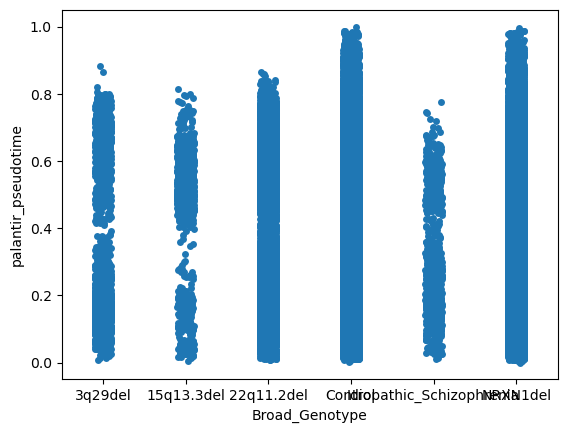

In [81]:
sns.stripplot(di_adata.obs, x='Broad_Genotype', y='palantir_pseudotime')

<Axes: xlabel='palantir_pseudotime', ylabel='Count'>

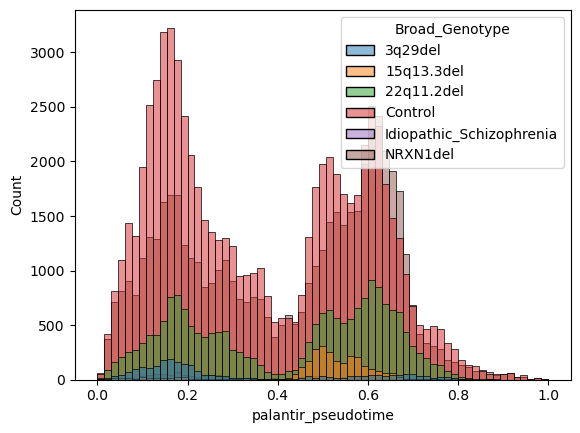

In [72]:
sns.histplot(di_adata.obs, hue='Broad_Genotype', x='palantir_pseudotime')

<Axes: xlabel='palantir_pseudotime', ylabel='Density'>

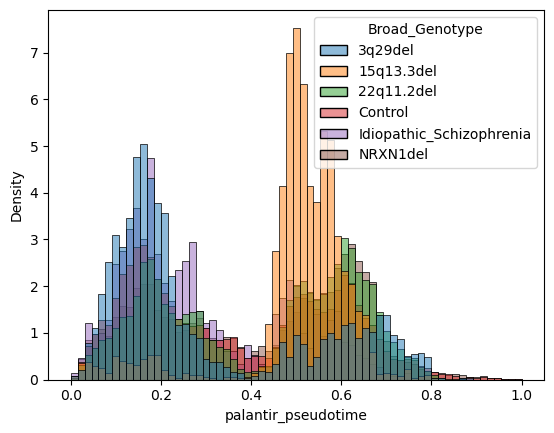

In [79]:
sns.histplot(
    data=di_adata.obs,
    x="palantir_pseudotime",
    hue="Broad_Genotype",
    stat="density",
    common_norm=False,
#    bins=40,
#    alpha=0.3
)

In [91]:
pt[['Manuscript', 'Broad_Genotype', 'Day']][80:120] #.summary()

,Manuscript,Broad_Genotype,Day
80,Notaras,Idiopathic_Schizophrenia,37.5
81,Sebastian,NRXN1del,100.0
82,Sebastian,NRXN1del,101.0
83,Sebastian,NRXN1del,22.0
84,Sebastian,NRXN1del,50.0
85,Sebastian,NRXN1del,100.0
86,Sebastian,NRXN1del,101.0
87,Sebastian,NRXN1del,22.0
88,Sebastian,NRXN1del,50.0
89,Rao,X22q11.2del,70.0


In [92]:
import pandas as pd

# pt is your donor-sample dataframe

effects = []

for manuscript in pt["Manuscript"].unique():

    sub = pt[pt["Manuscript"] == manuscript].copy()

    # manuscript must contain controls
    if "Control" not in sub["Broad_Genotype"].values:
        continue

    control = sub.loc[sub["Broad_Genotype"] == "Control", "mean_pseudotime"]

    control_mean = control.mean()

    for genotype in sorted(sub["Broad_Genotype"].unique()):

        if genotype == "Control":
            continue

        disease = sub.loc[sub["Broad_Genotype"] == genotype, "mean_pseudotime"]

        effects.append({
            "Manuscript": manuscript,
            "Genotype": genotype,
            "Control_mean": control_mean,
            "Disease_mean": disease.mean(),
            "Mean_shift": disease.mean() - control_mean,
            "Median_shift": disease.median() - control.median(),
            "n_control": len(control),
            "n_disease": len(disease)
        })

effects = pd.DataFrame(effects)

effects

,Manuscript,Genotype,Control_mean,Disease_mean,Mean_shift,Median_shift,n_control,n_disease
0,Khan,X22q11.2del,0.308661,0.285935,-0.022726,-0.022726,2,2
1,Fernando,NRXN1del,0.489597,0.479387,-0.010210,0.023338,2,8
2,Shin,X22q11.2del,0.359292,0.387345,0.028053,-0.002030,8,7
3,Purcell,X3q29del,0.412545,0.402629,-0.009916,-0.016551,4,4
4,Sebastian,NRXN1del,0.323971,0.365217,0.041246,0.036602,13,13
5,Sawada,Idiopathic_Schizophrenia,0.169557,0.270797,0.101239,0.100858,4,4
6,Walsh,X15q13.3del,0.573255,0.514749,-0.058506,-0.045970,6,2
7,Walsh,X22q11.2del,0.573255,0.546051,-0.027204,-0.014668,6,2
8,Notaras,Idiopathic_Schizophrenia,0.270738,0.274790,0.004053,-0.006060,4,3
9,Rao,X22q11.2del,0.452702,0.460071,0.007369,0.012346,6,6


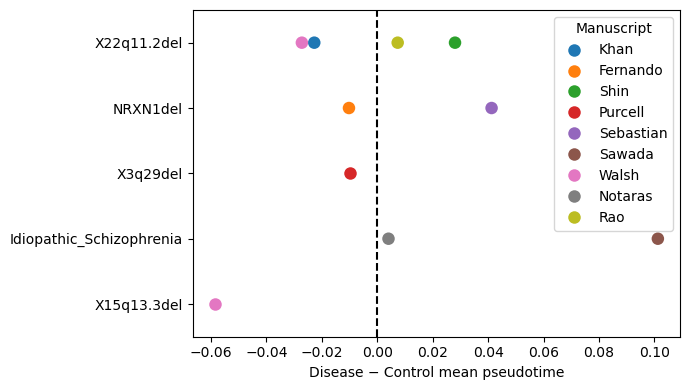

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

sns.stripplot(
    data=effects,
    x="Mean_shift",
    y="Genotype",
    hue="Manuscript",
    size=9,
    jitter=False
)

plt.axvline(0, color="black", ls="--")
plt.xlabel("Disease − Control mean pseudotime")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [41]:
def plot_gene_pseudotime_raw(
    adata,
    gene,
    pseudotime_key="palantir_pseudotime",
    groupby=None,
    n_bins=20,
    layer=None,
    use_raw=False,
    figsize=(8,4),
    ci="sem",
    legend=True,
    colors=None,  
    save=None):

    # --- expression extraction ---
    expr = (
        adata.raw[:, gene].X if use_raw else
        adata.layers[layer][:, adata.var_names.get_loc(gene)] if layer else
        adata[:, gene].X
    )

    expr = (
        expr.toarray().flatten()
        if not isinstance(expr, np.ndarray)
        else expr.flatten()
    )

    # --- dataframe ---
    df = pd.DataFrame({
        "pseudotime": adata.obs[pseudotime_key].values,
        "Expression": expr
    })

    if groupby:
        df[groupby] = adata.obs[groupby].values

    df["pt_bin"] = pd.cut(df["pseudotime"], bins=n_bins)

    # --- aggregation ---
    gb = [groupby, "pt_bin"] if groupby else ["pt_bin"]

    df_binned = (
        df.groupby(gb, observed=True)
          .agg(
              pseudotime=("pseudotime", "mean"),
              mean=("Expression", "mean"),
              std=("Expression", "std"),
              n=("Expression", "count")
          )
          .reset_index()
    )

    # --- CI ---
    df_binned["err"] = (
        df_binned["std"] / np.sqrt(df_binned["n"])
        if ci == "sem" else df_binned["std"]
    )

    # --- smoothing ---
    if groupby:
        df_binned["smooth"] = (
            df_binned.groupby(groupby)["mean"]
            .transform(
                lambda x: x.rolling(
                    3,
                    center=True,
                    min_periods=1
                ).mean()
            )
        )

        df_binned["err_smooth"] = (
            df_binned.groupby(groupby)["err"]
            .transform(
                lambda x: x.rolling(
                    3,
                    center=True,
                    min_periods=1
                ).mean()
            )
        )

    else:
        df_binned["smooth"] = (
            df_binned["mean"]
            .rolling(3, center=True, min_periods=1)
            .mean()
        )

        df_binned["err_smooth"] = (
            df_binned["err"]
            .rolling(3, center=True, min_periods=1)
            .mean()
        )

    # --- plot ---
    fig, ax = plt.subplots(figsize=figsize)

    if groupby:

        for i, (key, sub) in enumerate(df_binned.groupby(groupby)):

            # choose color
            if colors is not None:
                color = colors.get(key, None)
            else:
                color = None

            ax.plot(
                sub["pseudotime"],
                sub["smooth"],
                label=key,
                color=color
            )

            ax.fill_between(
                sub["pseudotime"],
                sub["smooth"] - sub["err_smooth"],
                sub["smooth"] + sub["err_smooth"],
                alpha=0.2,
                color=color
            )

        if legend:
            ax.legend(
                title=groupby,
                bbox_to_anchor=(1.05, 1),
                loc="upper left"
            )
        else:
            if ax.get_legend() is not None:
                ax.get_legend().remove()

    else:

        color = colors if isinstance(colors, str) else None

        ax.plot(
            df_binned["pseudotime"],
            df_binned["smooth"],
            color=color
        )

        ax.fill_between(
            df_binned["pseudotime"],
            df_binned["smooth"] - df_binned["err_smooth"],
            df_binned["smooth"] + df_binned["err_smooth"],
            alpha=0.2,
            color=color
        )

    # --- styling ---
    sns.despine()

    ax.set_title(f"{gene} expression over pseudotime")
    ax.set_ylabel("Smoothed expression")
    ax.set_xlabel("Pseudotime")

    # --- SAVE MODE ---
    if save:

        ax.set_title("")
        ax.set_ylabel("")
        ax.set_xlabel("")

        if ax.get_legend() is not None:
            ax.get_legend().remove()

        path = f"/home/deepak/datasets/scz_meta_analysis/panels/{save}.svg"

        plt.savefig(path, dpi=300, bbox_inches="tight")

    plt.show()

In [42]:
di_adata.obs['Path'] = di_adata.obs['Path'].astype('str')

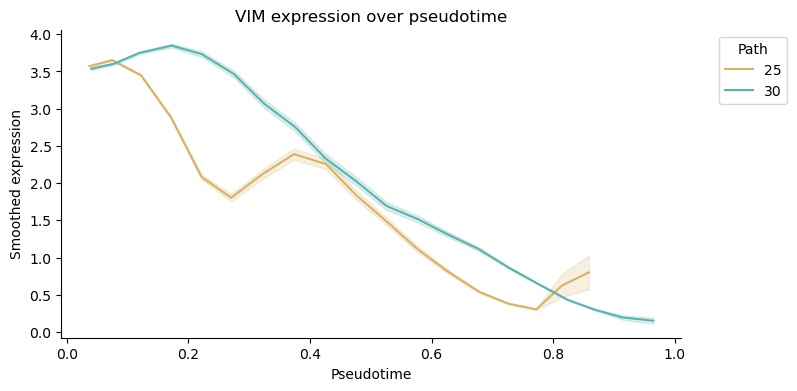

In [43]:
plot_gene_pseudotime_raw(di_adata, gene="VIM", colors = {'25':'#d8b365', '30':'#5ab4ac'},
                         groupby="Path", pseudotime_key="dpt_pseudotime")

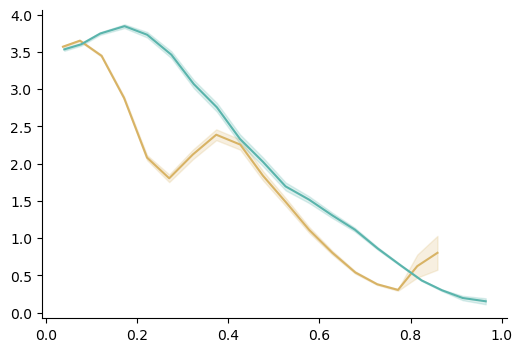

In [44]:
plot_gene_pseudotime_raw(di_adata, gene="VIM", groupby="Path", 
                         pseudotime_key="dpt_pseudotime", colors = {'25':'#d8b365', '30':'#5ab4ac'},
                         figsize=(6,4), save='Fig_6_VIM_di_lineplot')

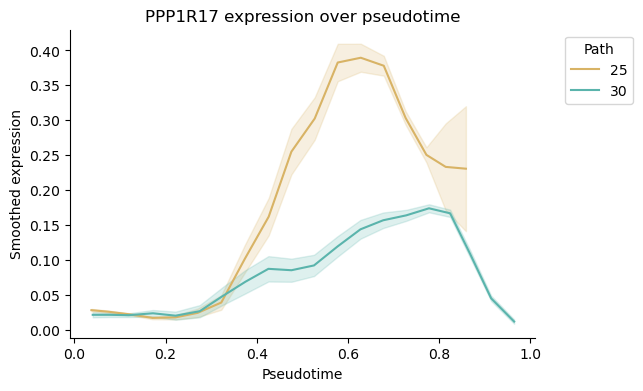

In [45]:
plot_gene_pseudotime_raw(di_adata, gene="PPP1R17", groupby="Path", colors = {'25':'#d8b365', '30':'#5ab4ac'},
                         pseudotime_key="dpt_pseudotime", figsize=(6,4))

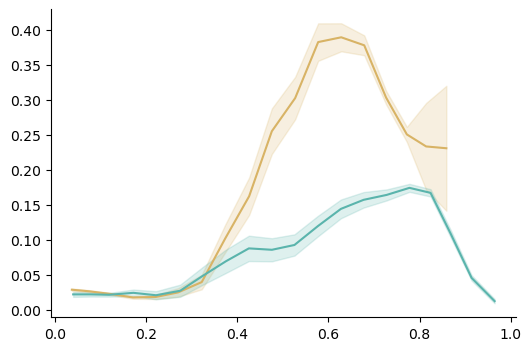

In [46]:
plot_gene_pseudotime_raw(di_adata, gene="PPP1R17", groupby="Path", figsize=(6,4), colors = {'25':'#d8b365', '30':'#5ab4ac'},
                         pseudotime_key="dpt_pseudotime", save='Fig_6_PPP1R17_di_lineplot')

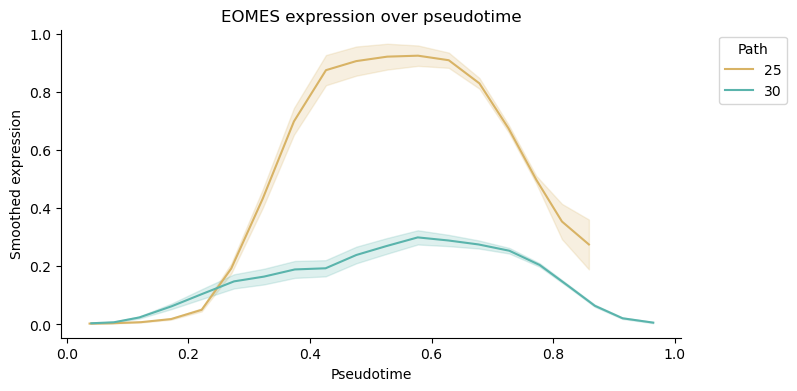

In [47]:
plot_gene_pseudotime_raw(di_adata, gene="EOMES", groupby="Path", colors = {'25':'#d8b365', '30':'#5ab4ac'},
                         pseudotime_key="dpt_pseudotime")

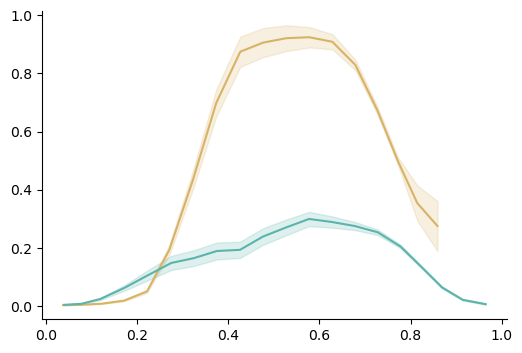

In [48]:
plot_gene_pseudotime_raw(di_adata, gene="EOMES", groupby="Path", figsize=(6,4), colors = {'25':'#d8b365', '30':'#5ab4ac'},
                         pseudotime_key="dpt_pseudotime", save='Fig_6_EOMES_di_lineplot')

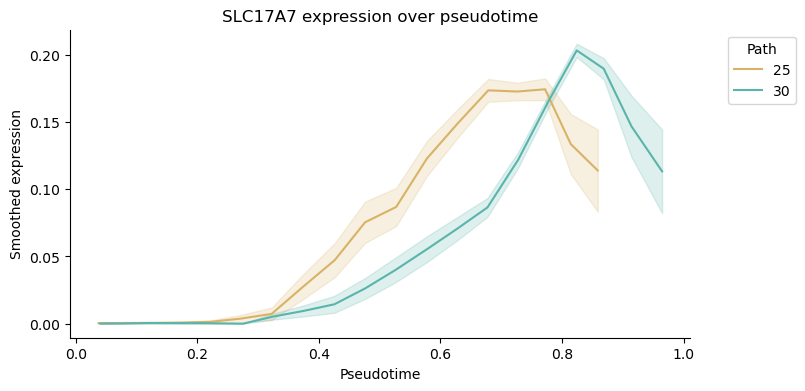

In [49]:
plot_gene_pseudotime_raw(di_adata, gene="SLC17A7", groupby="Path", colors = {'25':'#d8b365', '30':'#5ab4ac'},
                         pseudotime_key="dpt_pseudotime")

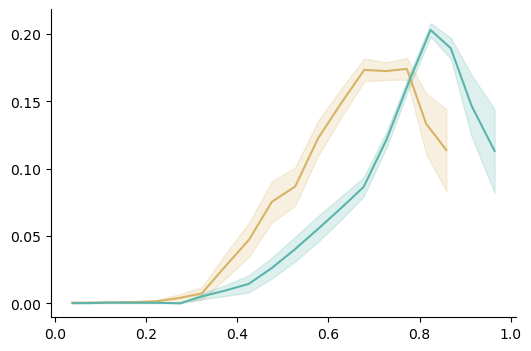

In [50]:
plot_gene_pseudotime_raw(di_adata, gene="SLC17A7", groupby="Path", figsize=(6,4),colors = {'25':'#d8b365', '30':'#5ab4ac'},
                         pseudotime_key="dpt_pseudotime", save='Fig_6_SLC17A7_di_lineplot')

/tmp/ipykernel_4587/3790268898.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["mean"]
/tmp/ipykernel_4587/3790268898.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["err"]
/tmp/ipykernel_4587/3790268898.py:101: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (key, sub) in enumerate(df_binned.groupby(groupby)):


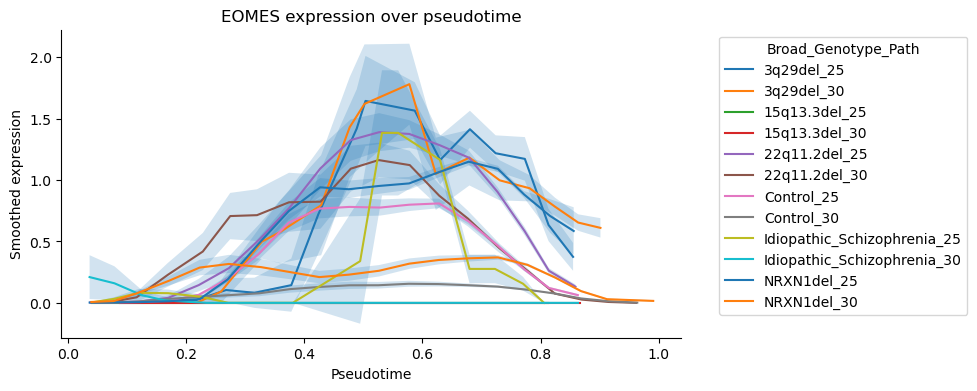

In [51]:
plot_gene_pseudotime_raw(di_adata, gene="EOMES", groupby="Broad_Genotype_Path", pseudotime_key="dpt_pseudotime")

/tmp/ipykernel_4587/3790268898.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["mean"]
/tmp/ipykernel_4587/3790268898.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["err"]
/tmp/ipykernel_4587/3790268898.py:101: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (key, sub) in enumerate(df_binned.groupby(groupby)):


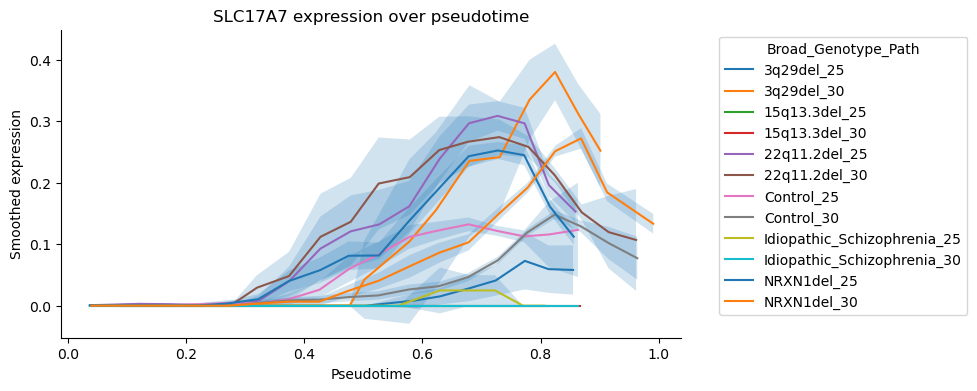

In [52]:
plot_gene_pseudotime_raw(di_adata, gene="SLC17A7", groupby="Broad_Genotype_Path", pseudotime_key="dpt_pseudotime")

/tmp/ipykernel_4587/3790268898.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["mean"]
/tmp/ipykernel_4587/3790268898.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["err"]
/tmp/ipykernel_4587/3790268898.py:101: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (key, sub) in enumerate(df_binned.groupby(groupby)):


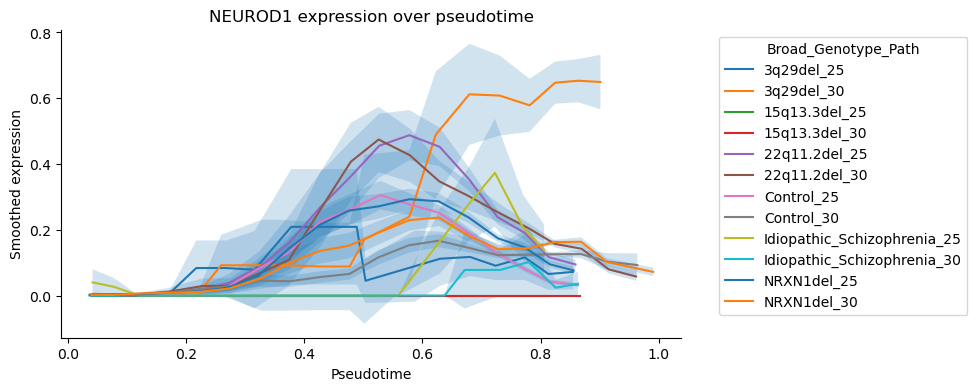

In [53]:
plot_gene_pseudotime_raw(di_adata, gene="NEUROD1", groupby="Broad_Genotype_Path", pseudotime_key="dpt_pseudotime")

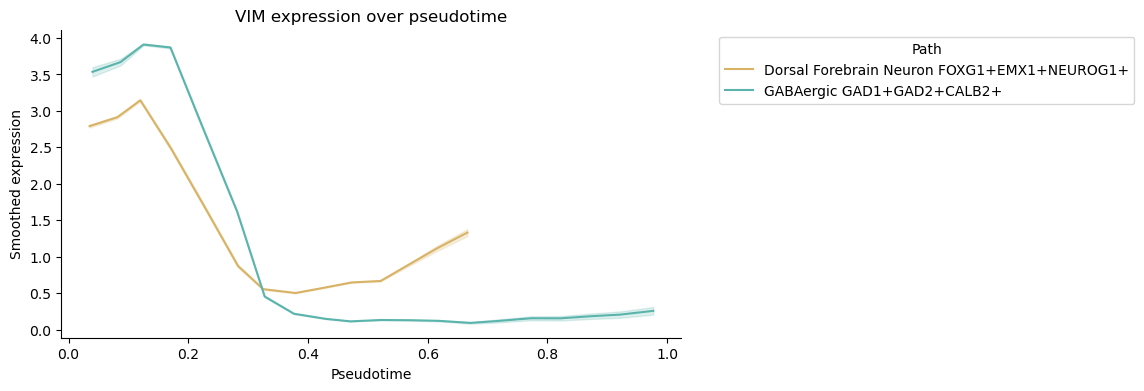

In [56]:
## Excitatory Inhibitory ##

plot_gene_pseudotime_raw(ei_adata, gene="VIM", groupby="Path", colors = {'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+':'#d8b365', 
                                                                         'GABAergic GAD1+GAD2+CALB2+':'#5ab4ac'})

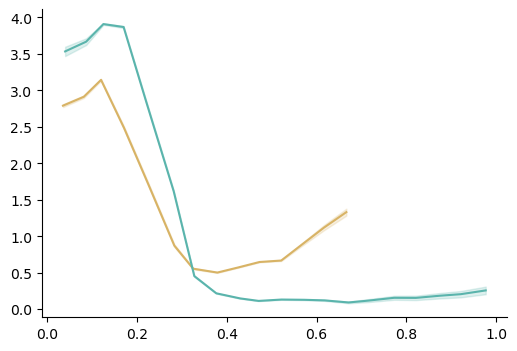

In [57]:
plot_gene_pseudotime_raw(ei_adata, gene="VIM", groupby="Path", figsize=(6,4), save='Fig_6_VIM_ei_lineplot',
                         colors = {'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+':'#d8b365', 
                                    'GABAergic GAD1+GAD2+CALB2+':'#5ab4ac'})

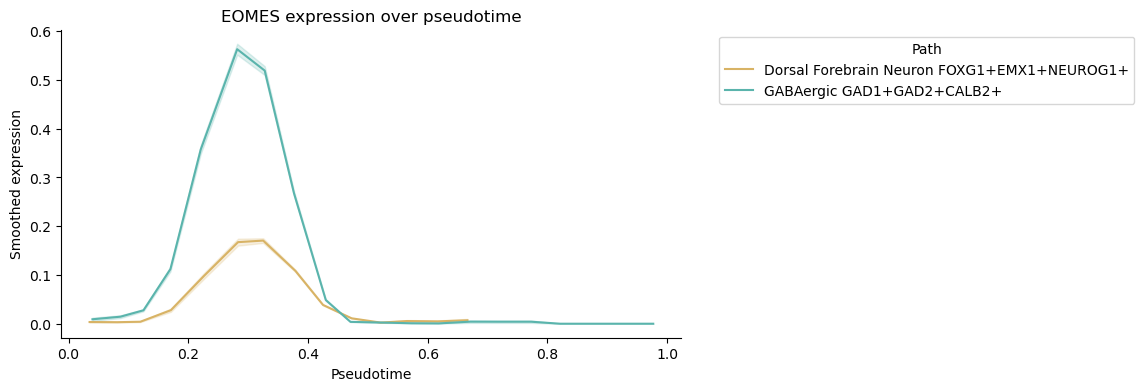

In [58]:
plot_gene_pseudotime_raw(ei_adata, gene="EOMES", groupby="Path", colors = {'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+':'#d8b365', 
                                                                         'GABAergic GAD1+GAD2+CALB2+':'#5ab4ac'})

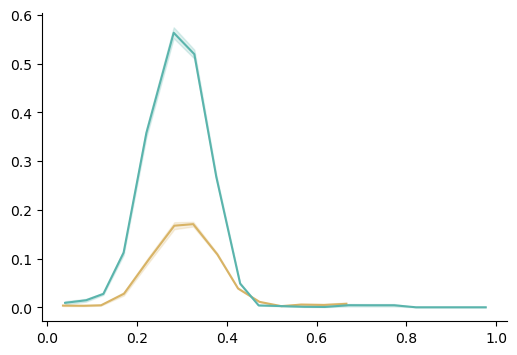

In [59]:
plot_gene_pseudotime_raw(ei_adata, gene="EOMES", groupby="Path", figsize=(6,4), save='Fig_6_EOMES_ei_lineplot', 
                         colors = {'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+':'#d8b365', 
                                                                         'GABAergic GAD1+GAD2+CALB2+':'#5ab4ac'})

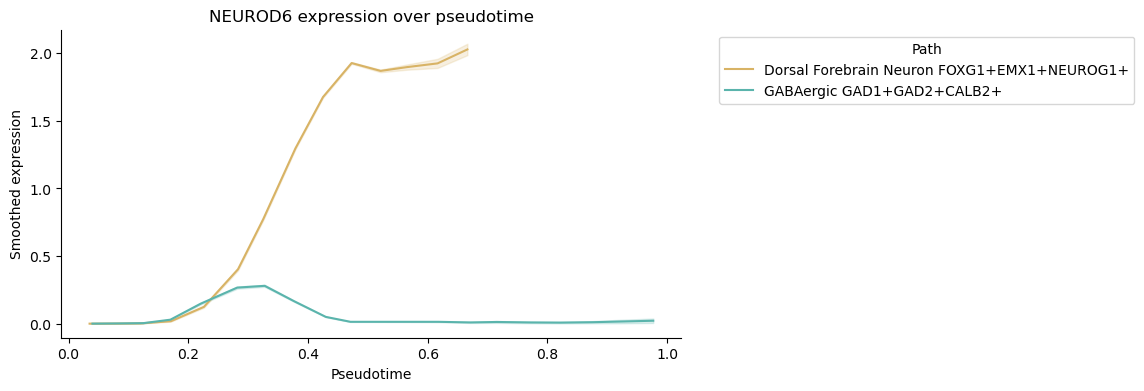

In [60]:
plot_gene_pseudotime_raw(ei_adata, gene="NEUROD6", groupby="Path", colors = {'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+':'#d8b365', 
                                                                         'GABAergic GAD1+GAD2+CALB2+':'#5ab4ac'})

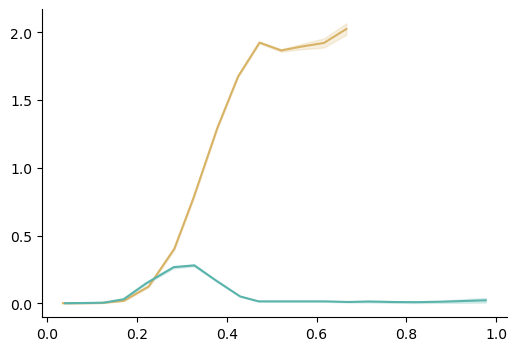

In [61]:
plot_gene_pseudotime_raw(ei_adata, gene="NEUROD6", groupby="Path", figsize=(6,4),
                         colors = {'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+':'#d8b365', 
                                                                         'GABAergic GAD1+GAD2+CALB2+':'#5ab4ac'},
                         save='Fig_6_NEUROD6_ei_lineplot')

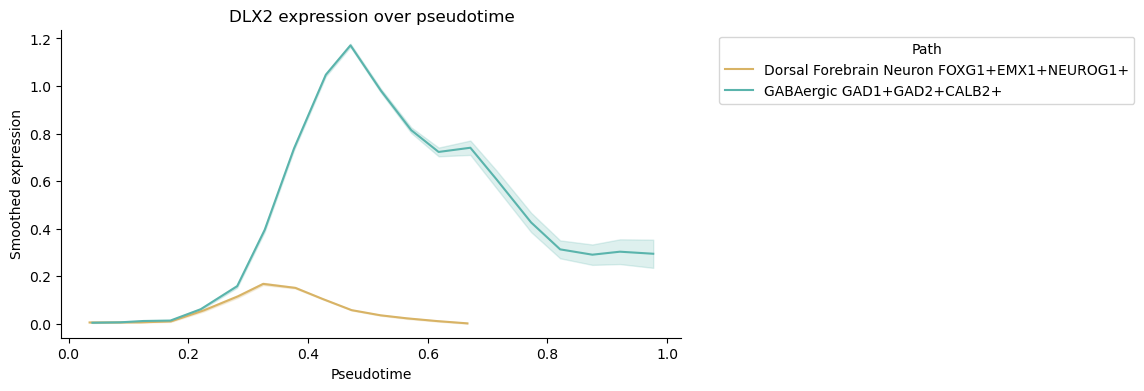

In [62]:
plot_gene_pseudotime_raw(ei_adata, gene="DLX2", groupby="Path", colors = {'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+':'#d8b365', 
                                                                         'GABAergic GAD1+GAD2+CALB2+':'#5ab4ac'})

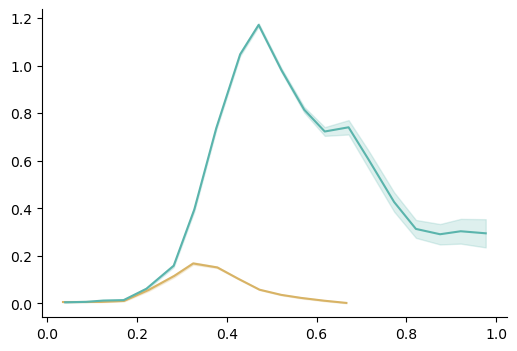

In [63]:
plot_gene_pseudotime_raw(ei_adata, gene="DLX2", groupby="Path",
                         colors = {'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+':'#d8b365', 
                                                                         'GABAergic GAD1+GAD2+CALB2+':'#5ab4ac'},
                         figsize=(6,4), save='Fig_6_DLX2_ei_lineplot')

/tmp/ipykernel_4587/3790268898.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["mean"]
/tmp/ipykernel_4587/3790268898.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["err"]
/tmp/ipykernel_4587/3790268898.py:101: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (key, sub) in enumerate(df_binned.groupby(groupby)):


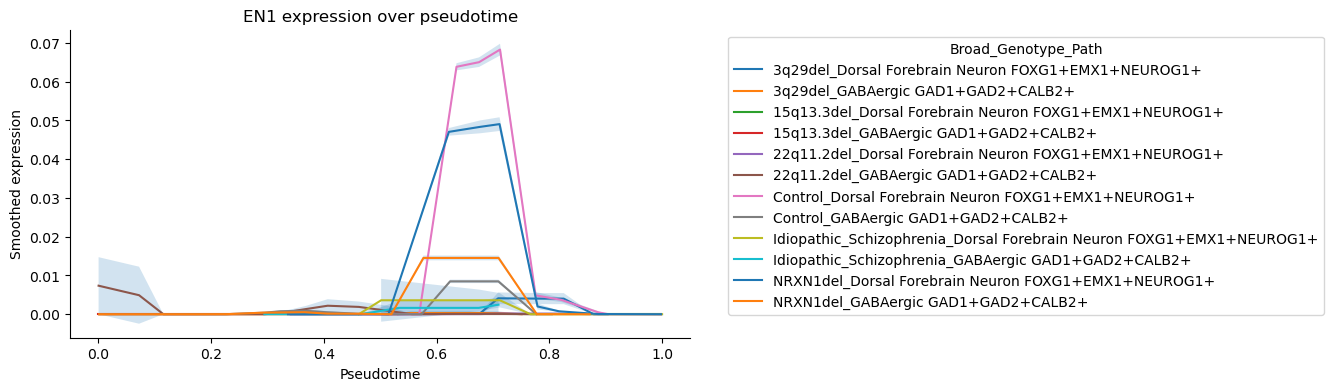

/tmp/ipykernel_4587/3790268898.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["mean"]
/tmp/ipykernel_4587/3790268898.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["err"]
/tmp/ipykernel_4587/3790268898.py:101: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (key, sub) in enumerate(df_binned.groupby(groupby)):


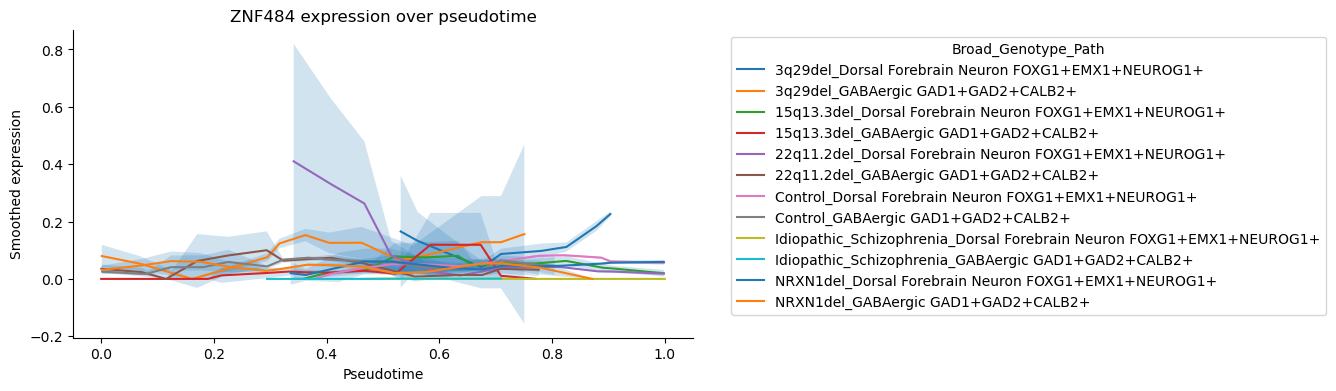

/tmp/ipykernel_4587/3790268898.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["mean"]
/tmp/ipykernel_4587/3790268898.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["err"]
/tmp/ipykernel_4587/3790268898.py:101: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (key, sub) in enumerate(df_binned.groupby(groupby)):


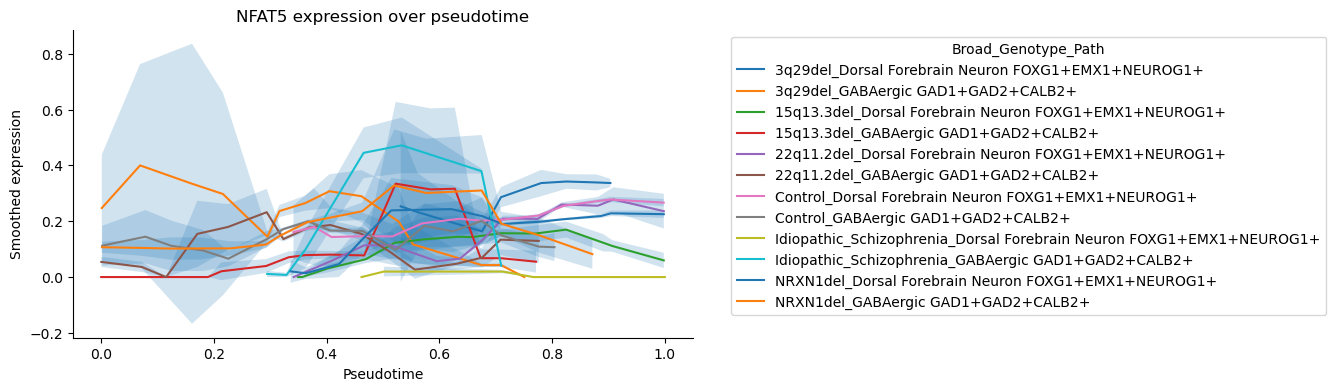

/tmp/ipykernel_4587/3790268898.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["mean"]
/tmp/ipykernel_4587/3790268898.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["err"]
/tmp/ipykernel_4587/3790268898.py:101: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (key, sub) in enumerate(df_binned.groupby(groupby)):


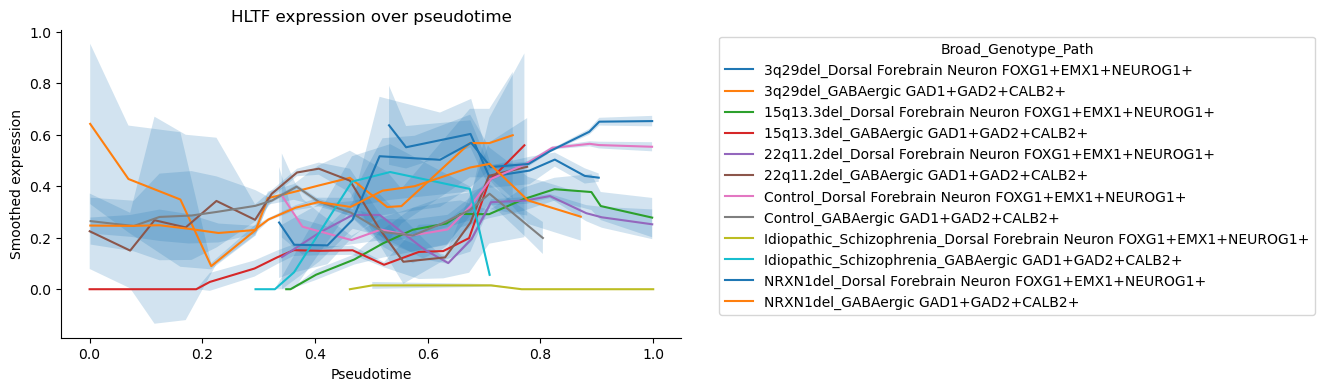

/tmp/ipykernel_4587/3790268898.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["mean"]
/tmp/ipykernel_4587/3790268898.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["err"]
/tmp/ipykernel_4587/3790268898.py:101: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (key, sub) in enumerate(df_binned.groupby(groupby)):


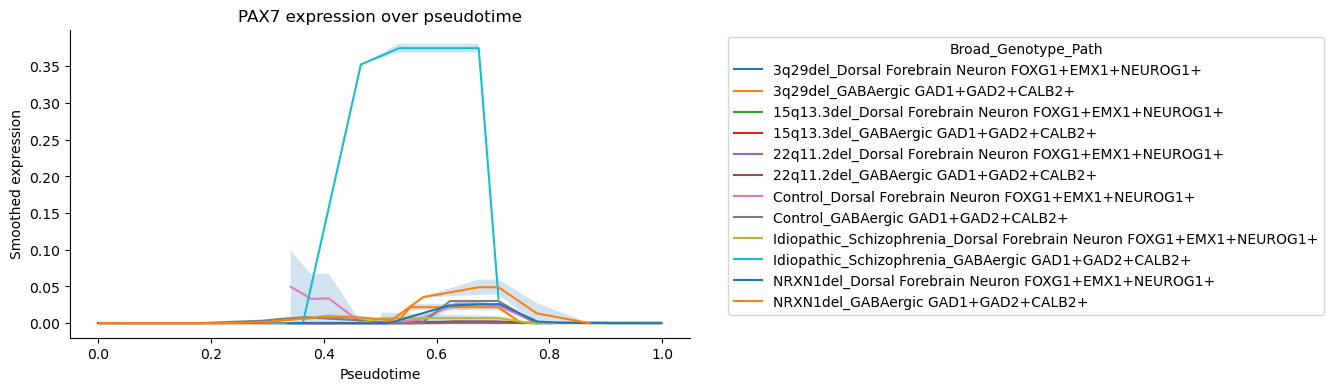

/tmp/ipykernel_4587/3790268898.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["mean"]
/tmp/ipykernel_4587/3790268898.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["err"]
/tmp/ipykernel_4587/3790268898.py:101: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (key, sub) in enumerate(df_binned.groupby(groupby)):


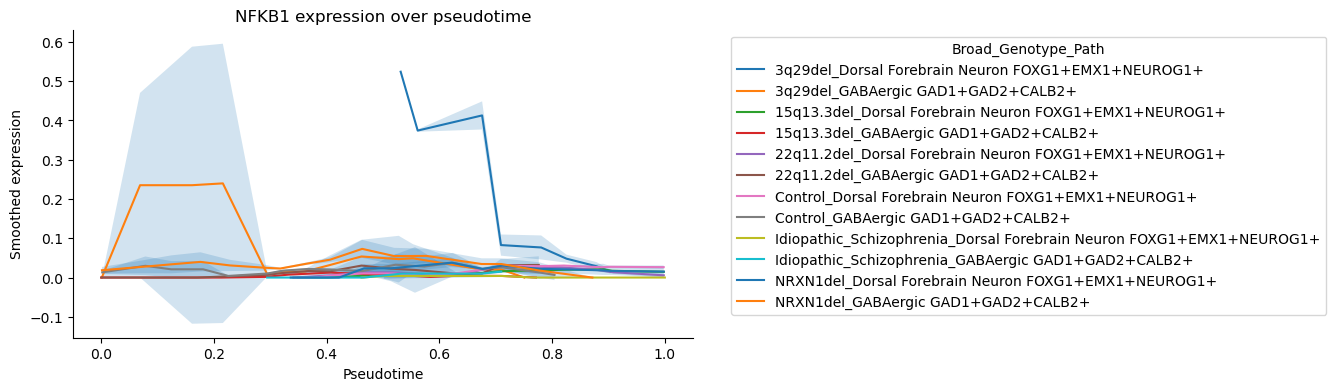

/tmp/ipykernel_4587/3790268898.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["mean"]
/tmp/ipykernel_4587/3790268898.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["err"]
/tmp/ipykernel_4587/3790268898.py:101: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (key, sub) in enumerate(df_binned.groupby(groupby)):


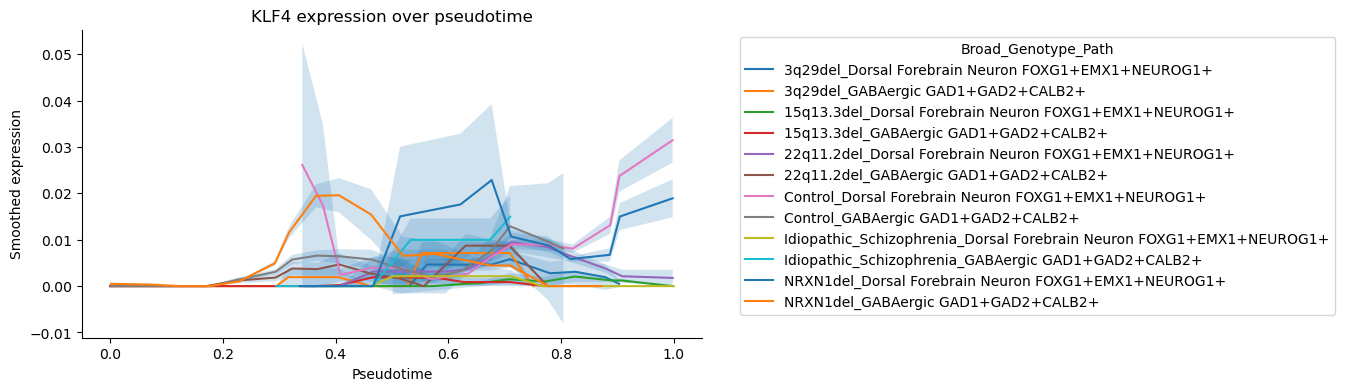

/tmp/ipykernel_4587/3790268898.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["mean"]
/tmp/ipykernel_4587/3790268898.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["err"]
/tmp/ipykernel_4587/3790268898.py:101: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (key, sub) in enumerate(df_binned.groupby(groupby)):


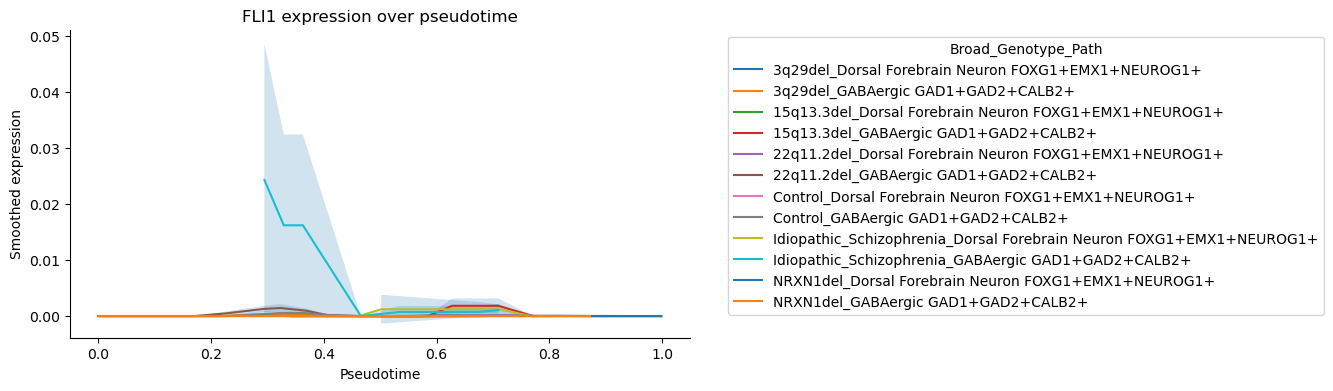

/tmp/ipykernel_4587/3790268898.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["mean"]
/tmp/ipykernel_4587/3790268898.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["err"]
/tmp/ipykernel_4587/3790268898.py:101: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (key, sub) in enumerate(df_binned.groupby(groupby)):


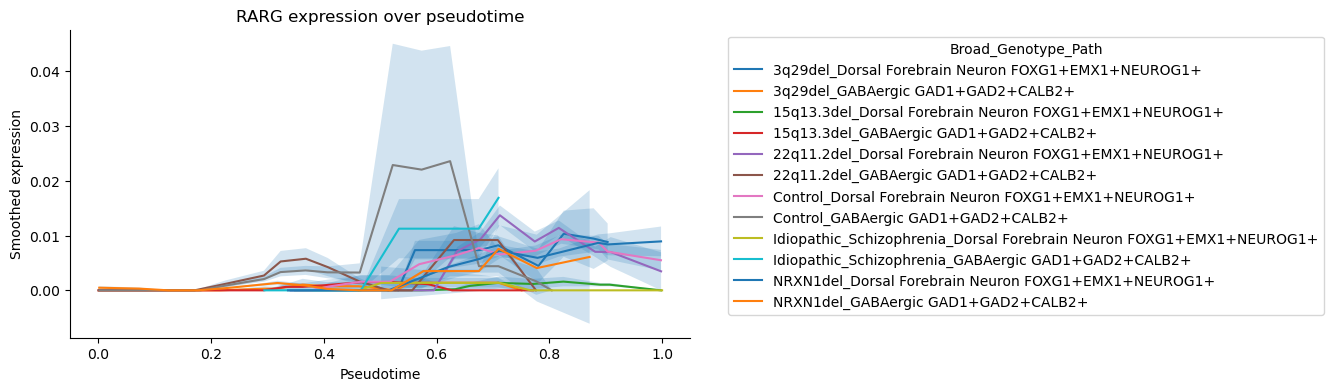

/tmp/ipykernel_4587/3790268898.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["mean"]
/tmp/ipykernel_4587/3790268898.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["err"]
/tmp/ipykernel_4587/3790268898.py:101: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (key, sub) in enumerate(df_binned.groupby(groupby)):


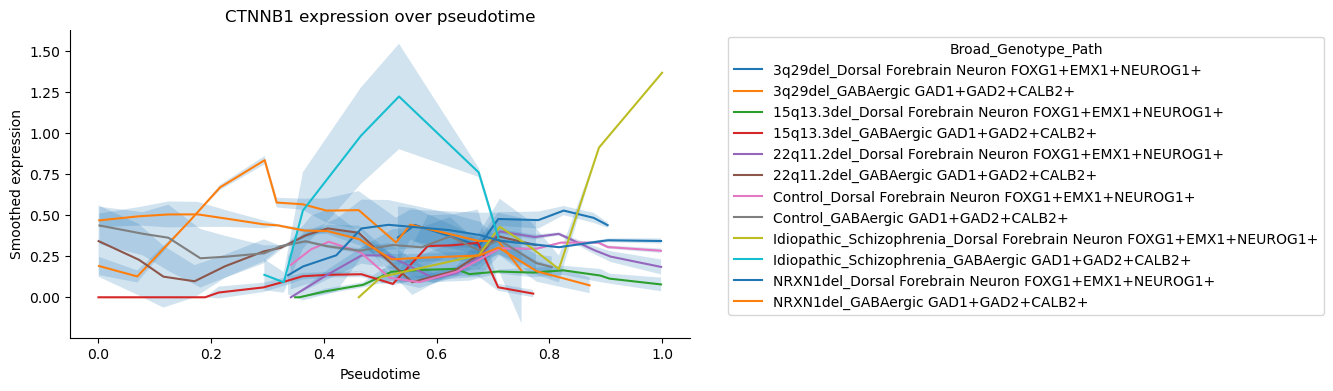

/tmp/ipykernel_4587/3790268898.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["mean"]
/tmp/ipykernel_4587/3790268898.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["err"]
/tmp/ipykernel_4587/3790268898.py:101: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (key, sub) in enumerate(df_binned.groupby(groupby)):


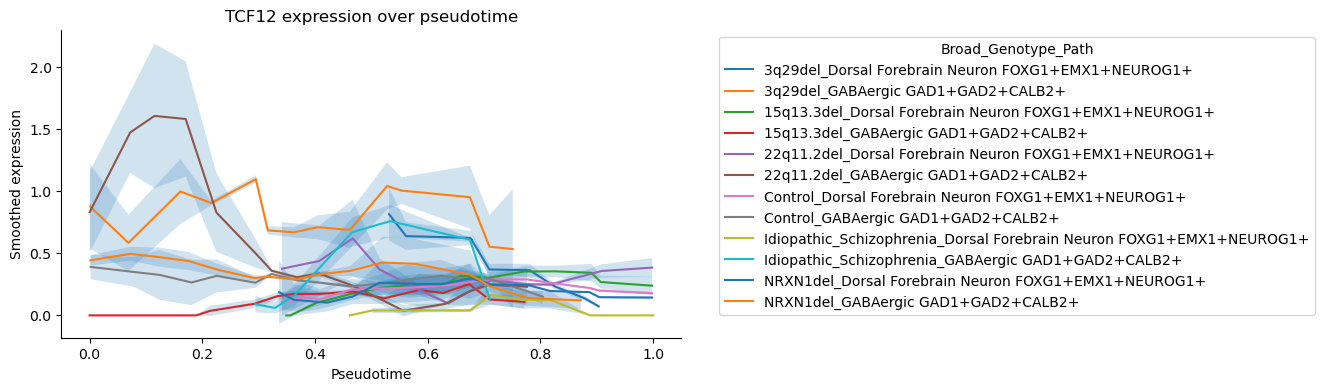

/tmp/ipykernel_4587/3790268898.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["mean"]
/tmp/ipykernel_4587/3790268898.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["err"]
/tmp/ipykernel_4587/3790268898.py:101: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (key, sub) in enumerate(df_binned.groupby(groupby)):


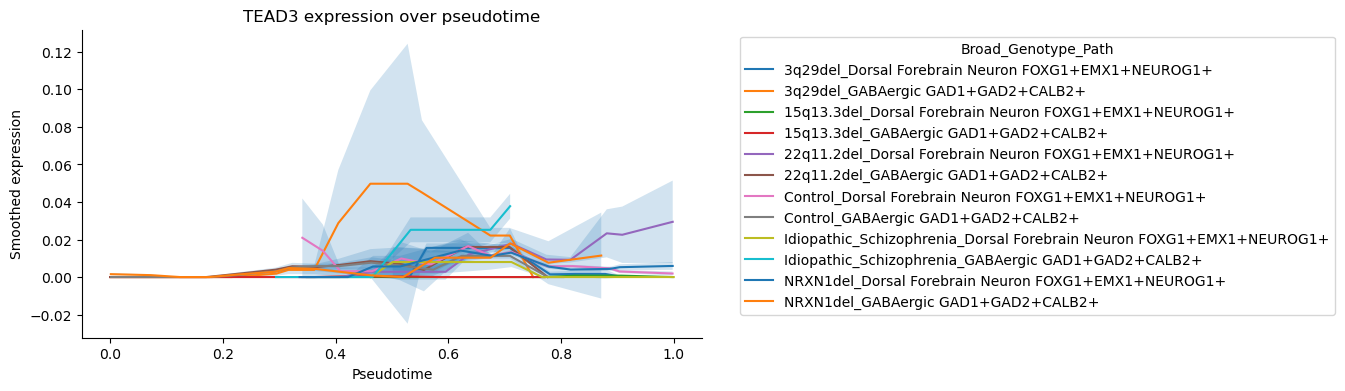

/tmp/ipykernel_4587/3790268898.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["mean"]
/tmp/ipykernel_4587/3790268898.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["err"]
/tmp/ipykernel_4587/3790268898.py:101: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (key, sub) in enumerate(df_binned.groupby(groupby)):


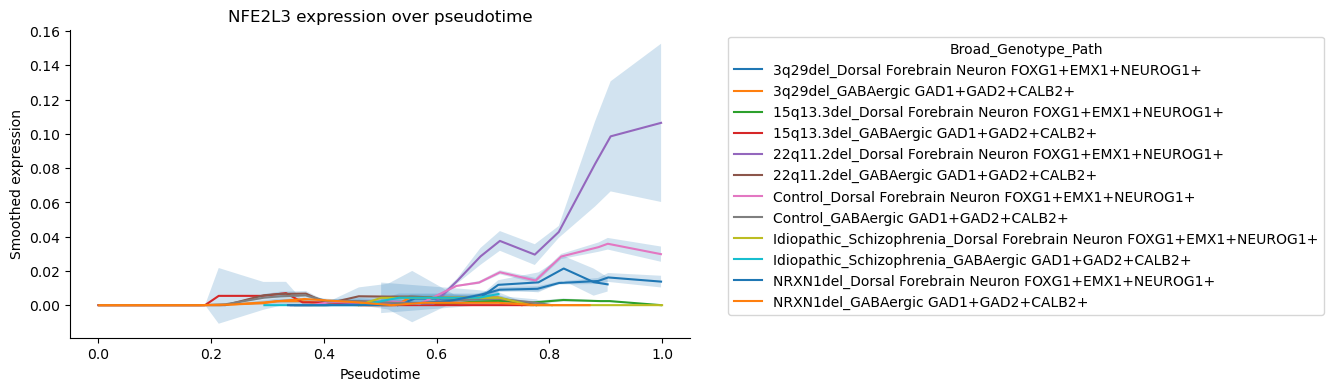

/tmp/ipykernel_4587/3790268898.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["mean"]
/tmp/ipykernel_4587/3790268898.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["err"]
/tmp/ipykernel_4587/3790268898.py:101: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (key, sub) in enumerate(df_binned.groupby(groupby)):


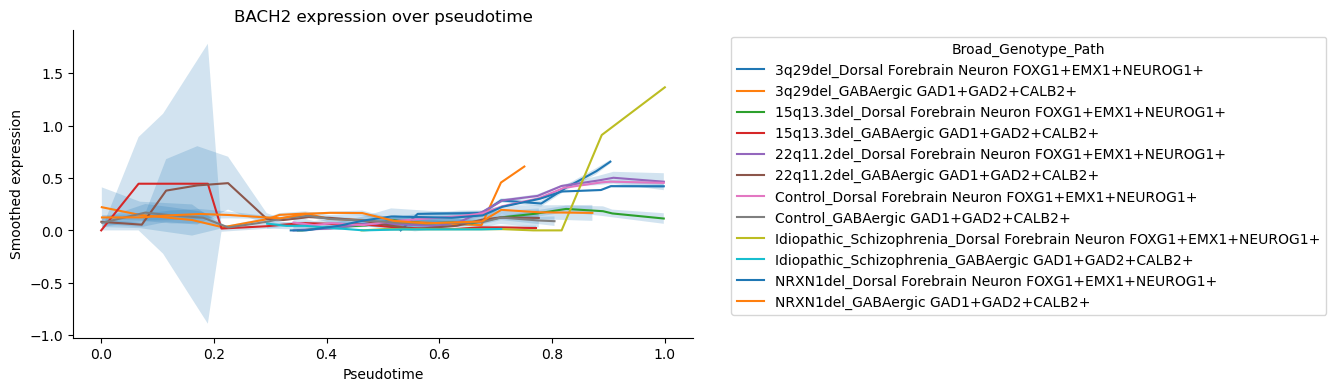

/tmp/ipykernel_4587/3790268898.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["mean"]
/tmp/ipykernel_4587/3790268898.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["err"]
/tmp/ipykernel_4587/3790268898.py:101: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (key, sub) in enumerate(df_binned.groupby(groupby)):


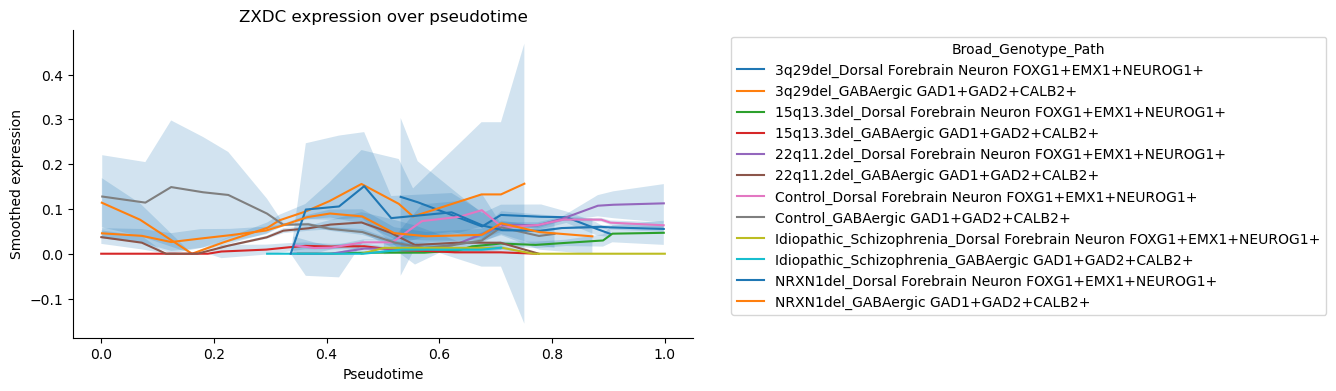

/tmp/ipykernel_4587/3790268898.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["mean"]
/tmp/ipykernel_4587/3790268898.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["err"]
/tmp/ipykernel_4587/3790268898.py:101: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (key, sub) in enumerate(df_binned.groupby(groupby)):


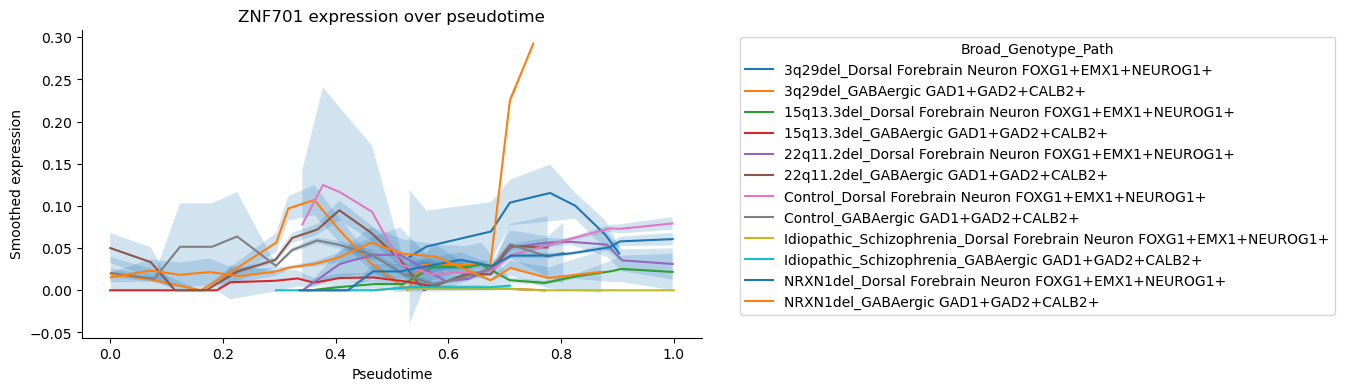

/tmp/ipykernel_4587/3790268898.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["mean"]
/tmp/ipykernel_4587/3790268898.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["err"]
/tmp/ipykernel_4587/3790268898.py:101: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (key, sub) in enumerate(df_binned.groupby(groupby)):


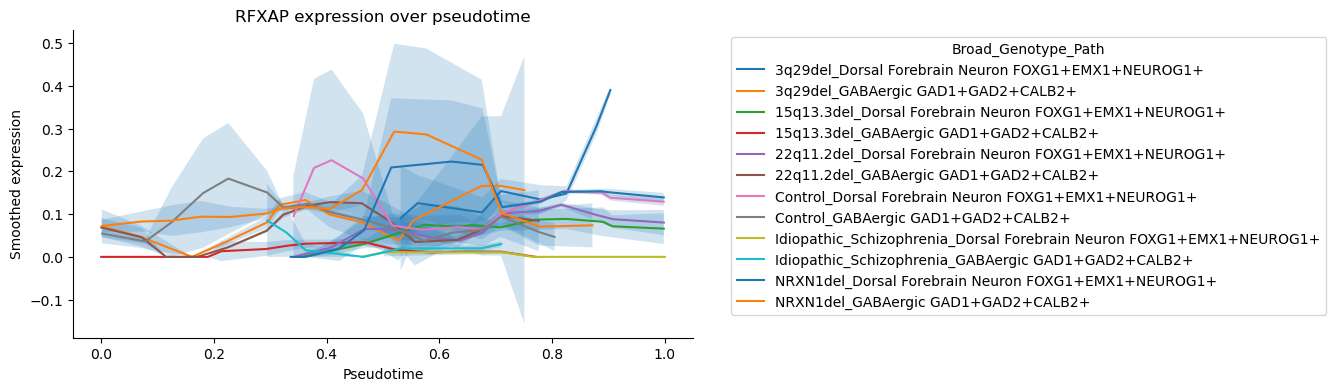

/tmp/ipykernel_4587/3790268898.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["mean"]
/tmp/ipykernel_4587/3790268898.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["err"]
/tmp/ipykernel_4587/3790268898.py:101: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (key, sub) in enumerate(df_binned.groupby(groupby)):


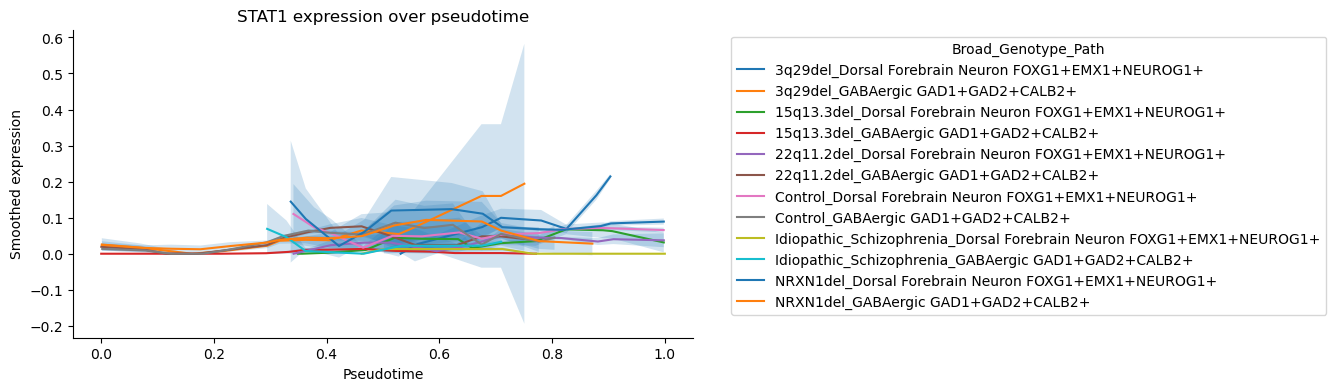

/tmp/ipykernel_4587/3790268898.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["mean"]
/tmp/ipykernel_4587/3790268898.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["err"]
/tmp/ipykernel_4587/3790268898.py:101: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (key, sub) in enumerate(df_binned.groupby(groupby)):


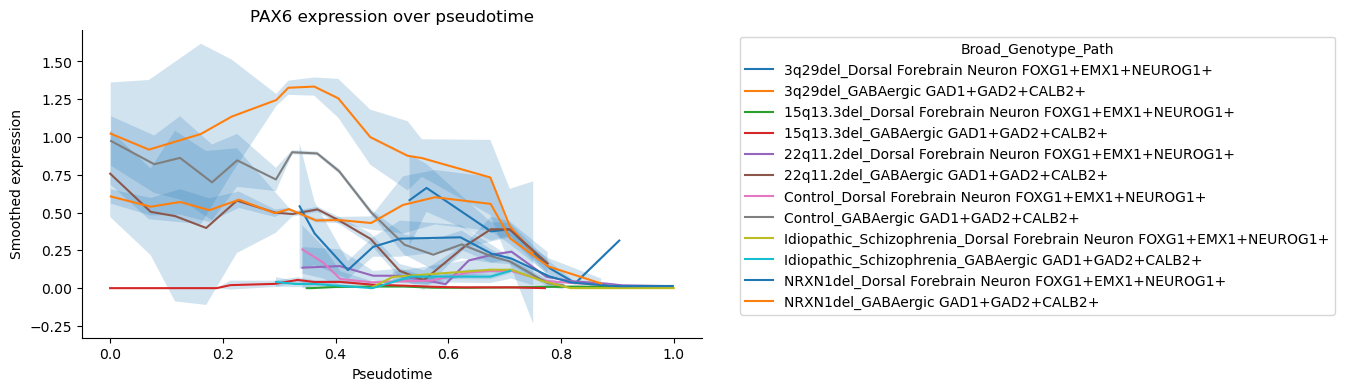

/tmp/ipykernel_4587/3790268898.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["mean"]
/tmp/ipykernel_4587/3790268898.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["err"]
/tmp/ipykernel_4587/3790268898.py:101: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (key, sub) in enumerate(df_binned.groupby(groupby)):


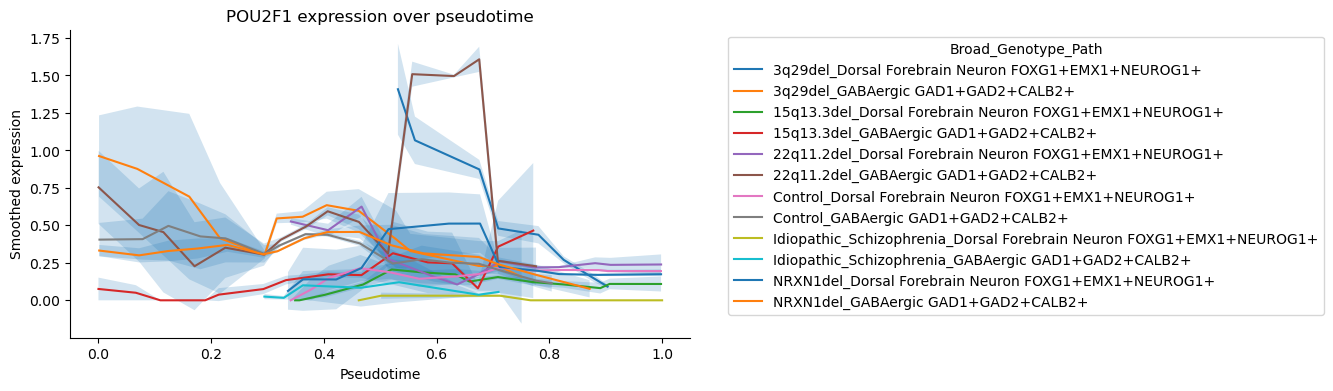

/tmp/ipykernel_4587/3790268898.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["mean"]
/tmp/ipykernel_4587/3790268898.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["err"]
/tmp/ipykernel_4587/3790268898.py:101: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (key, sub) in enumerate(df_binned.groupby(groupby)):


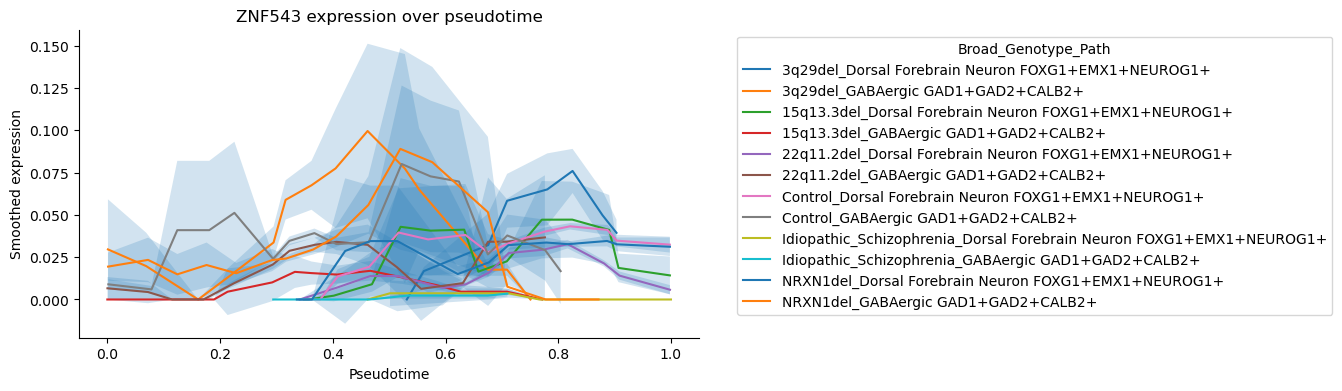

/tmp/ipykernel_4587/3790268898.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["mean"]
/tmp/ipykernel_4587/3790268898.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned.groupby(groupby)["err"]
/tmp/ipykernel_4587/3790268898.py:101: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (key, sub) in enumerate(df_binned.groupby(groupby)):

KeyboardInterrupt



In [64]:
## Excitatory Search ##

for GENE in [i.strip('(+)') for i in selected_cols_ei]:
    plot_gene_pseudotime_raw(ei_adata, gene=GENE, groupby='Broad_Genotype_Path', pseudotime_key='Excitatory')

In [ ]:
## Excitatory Lineage ##

# EN1, PAX7 #

In [ ]:
## Inhibitory Search ##

for GENE in [i.strip('(+)') for i in selected_cols_ei]:
    plot_gene_pseudotime_raw(ei_adata, gene=GENE, groupby='Broad_Genotype_Path', pseudotime_key='Inhibitory')

In [ ]:
for GENE in ['NKX2-1', 'ZNF669', 'RARG', 'TCF12', 'CTNNB1', 'NFE2L3']:
    plot_gene_pseudotime_raw(ei_adata, gene=GENE, groupby='Broad_Genotype_Path', pseudotime_key='Inhibitory')

In [ ]:
plot_gene_pseudotime_raw(ei_adata, gene='EOMES', groupby='Broad_Genotype_Path')

In [ ]:
for GENE in ['ZNF529', 'ZNF334', 'ZNF22']:
    plot_gene_pseudotime_raw(ei_adata, gene=GENE, groupby='Broad_Genotype_Path')